In [1]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import matplotlib.pyplot as plt

import deeplay as dl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [2]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


In [3]:
data = np.load('D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)

In [4]:
data.keys()

KeysView(NpzFile 'D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz' with keys: E, q, t, n)

In [5]:
index_min = 700
index_max = 1000

E = data['E'][index_min:index_max]
Q = data['q'][index_min:index_max]
T = data['t'][index_min:index_max] / 2e-7


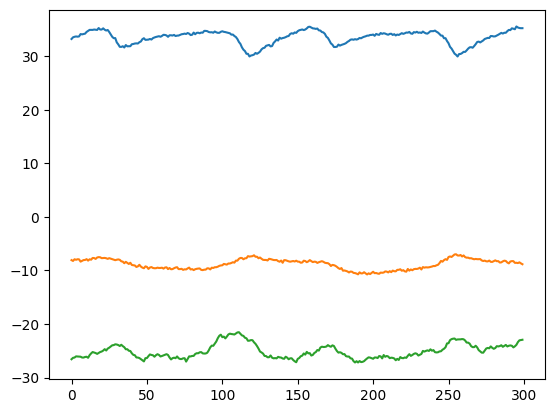

In [6]:
plt.plot(T)

In [7]:
N = data['n']

In [8]:
N.shape

(150, 174, 200)

In [9]:
E.shape

(300, 174, 200)

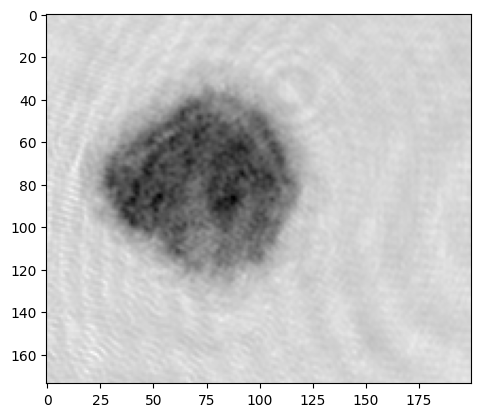

In [10]:
plt.imshow(E[0].real, cmap='gray')


In [11]:
N = torch.tensor(N, dtype=torch.float32, device=DEV)
E = torch.tensor(E, dtype=torch.complex64, device=DEV)
Q = torch.tensor(Q, dtype=torch.float32, device=DEV)
T = torch.tensor(T, dtype=torch.float32, device=DEV)


In [12]:
N.shape

torch.Size([150, 174, 200])

In [13]:
#N = torch.moveaxis(N, 0, 2)  # Move the last dimension to the end

In [14]:
q_new = Q.clone()

q_new[...,1] = Q[...,2]
q_new[...,2] = Q[...,3]
q_new[...,3] = Q[...,1]

In [15]:
t_new = T.clone()

t_new[..., 0] = T[...,0] #0
t_new[..., 1] = T[..., 2]
t_new[..., 2] = T[..., 1]

In [16]:
t_new[0]

tensor([ 33.2281, -26.5853,  -8.0743], device='cuda:0')

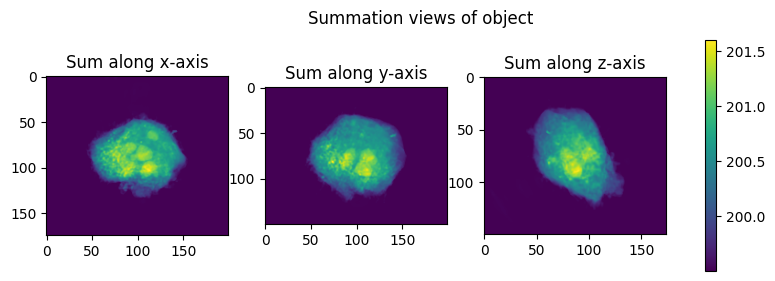

In [17]:
tomodpdt.plotting.plot_sum_object(N.cpu().numpy())

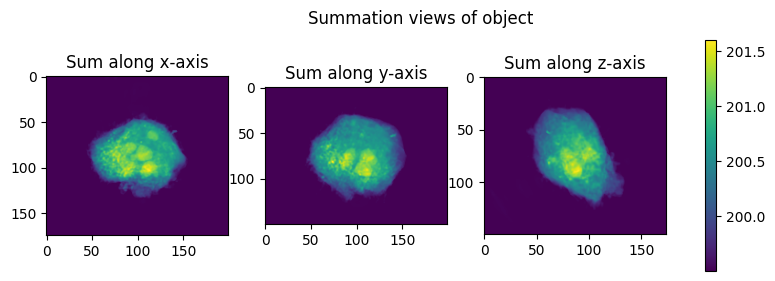

In [18]:
tomodpdt.plotting.plot_sum_object(N.cpu().numpy())

In [19]:
import tomodpdt.forward_module as FM

In [20]:
nx, ny, nz = N.shape

In [21]:
nx, ny, nz

(150, 174, 200)

In [22]:
forward_model = FM.ForwardModelSimple(nx=nx, ny=ny, nz=nz)

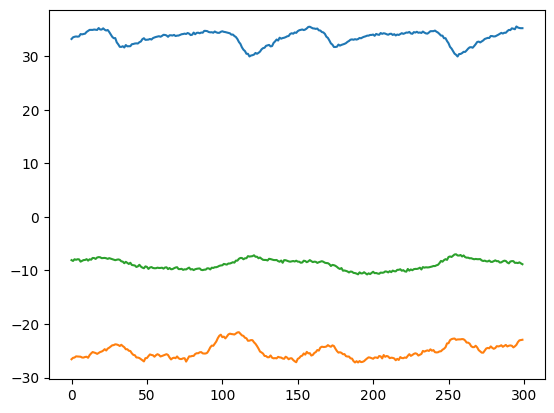

In [23]:
plt.plot(t_new.cpu().numpy())

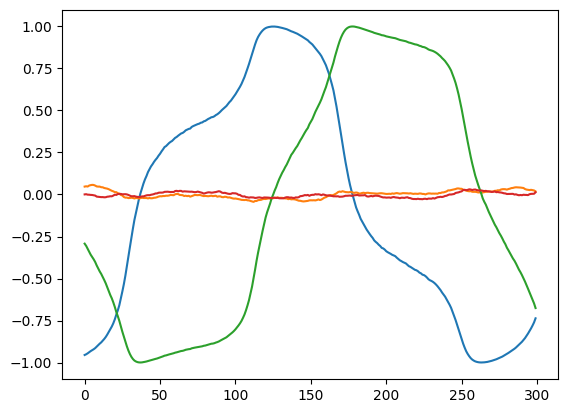

In [24]:
plt.plot(q_new.cpu().numpy())

In [25]:
q_new = Q.clone()

q_new[...,1] = Q[...,3]
q_new[...,2] = Q[...,2]
q_new[...,3] = Q[...,1]

t_new = T.clone()
t_new[..., 0] = T[...,2] #0
t_new[..., 1] = T[..., 1]
t_new[..., 2] = T[..., 0]

In [26]:
k=150

In [27]:
q_new[k]

tensor([ 0.9006,  0.4334, -0.0344, -0.0035], device='cuda:0')

In [28]:
t_new[k]

tensor([-26.5159,  -8.3500,  34.6886], device='cuda:0')

In [29]:
NN = N

In [30]:
N = NN

In [31]:
#N = torch.moveaxis(N, 0, 2)  # Move the last dimension to the end

In [32]:
nx, ny, nz = N.shape

In [33]:
nx

150

In [34]:
forward_model = FM.ForwardModelSimple(nx=nz, ny=ny, nz=nx)

In [35]:
N.shape

torch.Size([150, 174, 200])

In [36]:
volume_new = forward_model.apply_rotation_translation(volume=N, q=q_new[k], translations=t_new[k])
#volume_new = forward_model.apply_rotation_translation(volume=N, q=torch.tensor([1, 0, 0, 0], dtype=torch.float32).to(DEV), translations=torch.tensor([0, 0, 0], dtype=torch.float32).to(DEV))

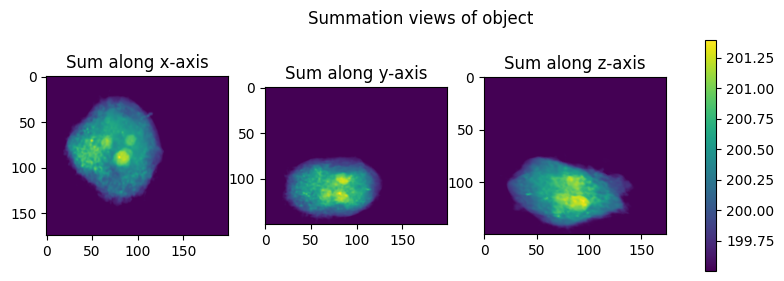

In [37]:
tomodpdt.plotting.plot_sum_object(volume_new.cpu().numpy())

In [38]:
volume_new.cpu().sum(dim=2).shape

torch.Size([150, 174])

In [39]:
N.shape

torch.Size([150, 174, 200])

In [40]:
volume_new.shape

torch.Size([150, 174, 200])

In [41]:
volume_new.shape

torch.Size([150, 174, 200])

In [42]:
E.shape

torch.Size([300, 174, 200])

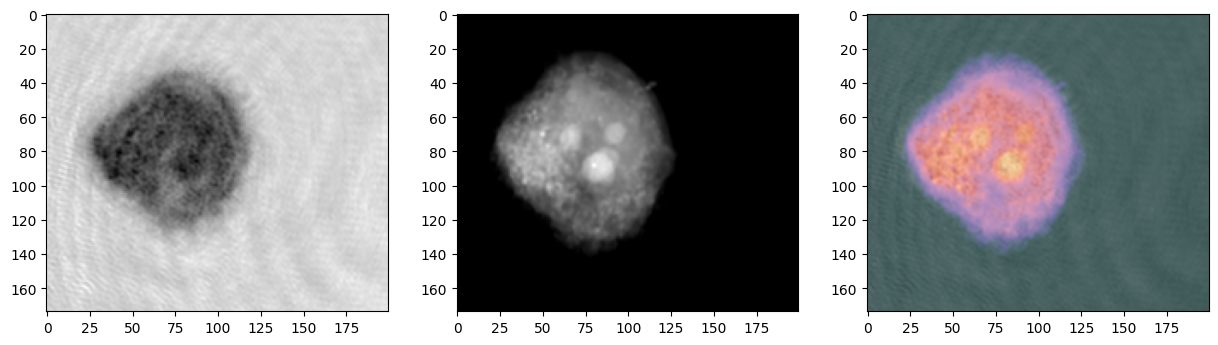

In [47]:
# Compare with original projection and the volume
plt.subplots(1,3, figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(E[k].cpu().real, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(volume_new.cpu().sum(dim=0).real, cmap='gray')
plt.subplot(1,3,3)

#Overlay
plt.imshow(E[k].cpu().real, cmap='BrBG', alpha=0.5)
plt.imshow(volume_new.cpu().sum(dim=0).real, cmap='magma', alpha=0.5)
plt.show()



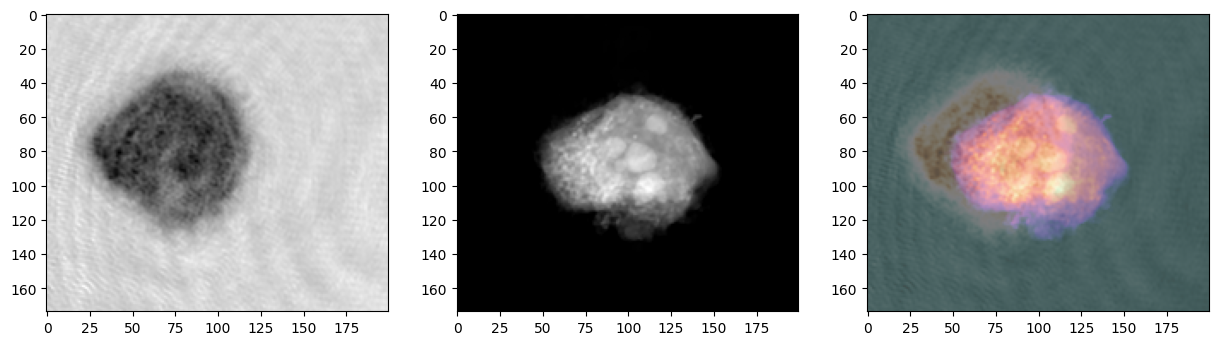

In [44]:
# Compare with original projection and the volume
plt.subplots(1,3, figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(E[k].cpu().real, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(N.cpu().sum(dim=0).real, cmap='gray')
plt.subplot(1,3,3)

#Overlay
plt.imshow(E[k].cpu().real, cmap='BrBG', alpha=0.5)
plt.imshow(N.cpu().sum(dim=0).real, cmap='magma', alpha=0.5)
plt.show()

In [67]:
volume = N.moveaxis(0, 2)  # Move the last dimension to the end

In [68]:
volume.shape

torch.Size([174, 200, 150])

In [99]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model



# Setup the optics
optics_setttings = setup_optics(
        shape=volume.shape, 
        padding_xy=volume.shape[0] // 2, 
        microscopy_regime='Brightfield', 
        NA=1.1, 
        wavelength=520e-9, 
        resolution=400e-9, 
        magnification=1, 
        return_field=True)

# Generate the imaging model
brightfield_model = imaging_model(optics_setup=optics_setttings)

In [100]:
field = brightfield_model(volume)

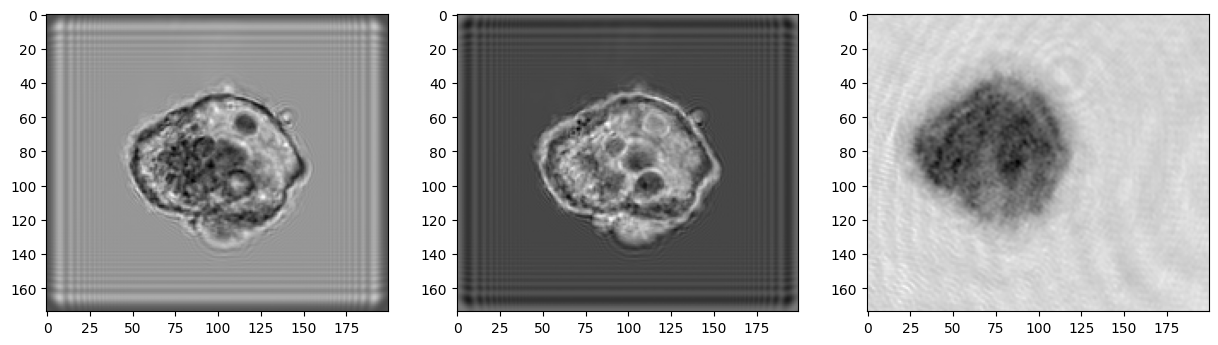

In [101]:
plt.subplots(1,3, figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(field.cpu().real, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(field.cpu().imag, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(E[0].cpu().real, cmap='gray')